# Example: Sampling with FiQCISampler

For configuration options and mitigation levels, see the [FiQCISampler guide](../pages/FiQCISamplerUsage.rst).

## Import everything needed

In [ ]:
from fiqci.ems import FiQCISampler
from iqm.qiskit_iqm import IQMProvider
from qiskit import QuantumCircuit, transpile

## Initialise FiQCISampler

In [ ]:
url = None
quantum_computer = None

# Connect to an IQM quantum computer using the provider
if url is not None and quantum_computer is not None:
	provider = IQMProvider(url=url, quantum_computer=quantum_computer)
	backend = provider.get_backend()
else:
	# Or using a noisy simulator
	from iqm.qiskit_iqm import IQMFakeAdonis

	backend = IQMFakeAdonis()

# Initialise FiQCI sampler with mitigation level 1 (readout error mitigation)
sampler = FiQCISampler(backend=backend, mitigation_level=1)

# We can view the default settings enabled for mitigation level 1
sampler.mitigator_options

## Mitigated Bell State

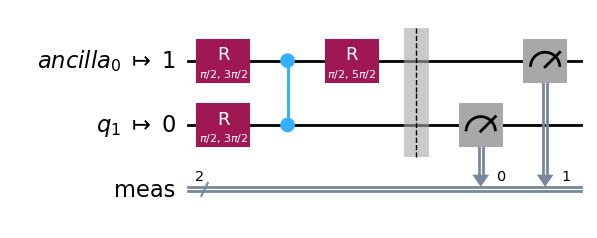

In [3]:
# Create a Bell state circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Transpile for backend
qc_transpiled = transpile(qc, backend=backend, optimization_level=3)

qc_transpiled.draw("mpl")

In [ ]:
# Execute on FiQCI Sampler
job = sampler.run([qc_transpiled], shots=2**10)

# Retrieve mitigated counts
mitigated_counts = job.result().get_counts()

print("Mitigated counts:", mitigated_counts)

## Manually configure mitigation options

In [ ]:
# Initialise FiQCI sampler
sampler = FiQCISampler(backend=backend, mitigation_level=0)

# Config rem
sampler.rem(enabled=True, calibration_shots=2**10)

# Print current mitigator options
sampler.mitigator_options